#TASK 1

Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')
################################################################################
import os

imdb_dir = '/content/drive/MyDrive/aclImdb'
train_dir = os.path.join(imdb_dir, 'train')

labels = []
texts = []

for label_type in ['neg', 'pos']:
    dir_name = os.path.join(train_dir, label_type)
    for fname in os.listdir(dir_name):
        if fname[-4:] == '.txt':
            f = open(os.path.join(dir_name, fname))
            texts.append(f.read())
            f.close()
            if label_type == 'neg':
                labels.append(0)
            else:
                labels.append(1)
################################################################################
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

maxlen = 100  # We will cut reviews after 100 words
training_samples = 200  # We will be training on 200 samples
validation_samples = 10000  # We will be validating on 10000 samples
max_words = 10000  # We will only consider the top 10,000 words in the dataset

tokenizer = Tokenizer(num_words=max_words)
# fit_on_texts :
# This method creates the vocabulary index based on word frequency,
# lower integer means more frequent word
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)

word_index = tokenizer.word_index
print('Found %s unique tokens.' % len(word_index))

data = pad_sequences(sequences, maxlen=maxlen)

labels = np.asarray(labels)
print('Shape of data tensor:', data.shape)
print('Shape of label tensor:', labels.shape)

# Split the data into a training set and a validation set
# But first, shuffle the data, since we started from data
# where sample are ordered (all negative first, then all positive).
indices = np.arange(data.shape[0])
np.random.shuffle(indices)
data = data[indices]
labels = labels[indices]

x_train = data[:training_samples]
y_train = labels[:training_samples]
x_val = data[training_samples: training_samples + validation_samples]
y_val = labels[training_samples: training_samples + validation_samples]
################################################################################
glove_dir = '/content/drive/MyDrive/Colab Notebooks/glove.6B/'

embeddings_index = {}
f = open(os.path.join(glove_dir, 'glove.6B.100d.txt'))
for line in f:
    values = line.split()
    word = values[0]
    coefs = np.asarray(values[1:], dtype='float32')
    embeddings_index[word] = coefs
f.close()

print('Found %s word vectors.' % len(embeddings_index))
################################################################################
embedding_dim = 100

embedding_matrix = np.zeros((max_words, embedding_dim))
for word, i in word_index.items():
    embedding_vector = embeddings_index.get(word)
    # Take only 10,000 most frequently used words
    if i < max_words:
        if embedding_vector is not None:
            # Words not found in embedding index will be all-zeros.
            embedding_matrix[i] = embedding_vector
################################################################################
test_dir = os.path.join(imdb_dir, 'test')

labels = []
texts = []

for label_type in ['neg', 'pos']:
    dir_name = os.path.join(test_dir, label_type)
    for fname in sorted(os.listdir(dir_name)):
        if fname[-4:] == '.txt':
            f = open(os.path.join(dir_name, fname))
            texts.append(f.read())
            f.close()
            if label_type == 'neg':
                labels.append(0)
            else:
                labels.append(1)

sequences = tokenizer.texts_to_sequences(texts)
x_test = pad_sequences(sequences, maxlen=maxlen)
y_test = np.asarray(labels)

Mounted at /content/drive
Found 88582 unique tokens.
Shape of data tensor: (25000, 100)
Shape of label tensor: (25000,)
Found 400000 word vectors.


Original Model - Accuracy: 0.5030196309089661

In [65]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense

model = Sequential()
model.add(Embedding(max_words, embedding_dim, input_length=maxlen))
model.add(Flatten())
model.add(Dense(32, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['acc'])
history = model.fit(x_train, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_data=(x_val, y_val))
model.save_weights('/content/sample_data/pre_trained_glove_model.weights.h5')
model.layers[0].set_weights([embedding_matrix])
model.layers[0].trainable = False
print("Expected embedding shape:", model.layers[0].get_weights()[0].shape)
print("Actual embedding matrix shape:", embedding_matrix.shape)

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 269ms/step - acc: 0.5245 - loss: 0.6935 - val_acc: 0.4974 - val_loss: 0.6938
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 300ms/step - acc: 0.9790 - loss: 0.6426 - val_acc: 0.5106 - val_loss: 0.6989
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 189ms/step - acc: 0.9621 - loss: 0.5400 - val_acc: 0.5131 - val_loss: 0.7096
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 189ms/step - acc: 0.9855 - loss: 0.3578 - val_acc: 0.5143 - val_loss: 0.7029
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 188ms/step - acc: 0.9973 - loss: 0.1776 - val_acc: 0.5202 - val_loss: 0.7053
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 231ms/step - acc: 1.0000 - loss: 0.0791 - val_acc: 0.5151 - val_loss: 0.7538
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 198ms/step - acc: 1.0000 - loss: 0.0370 - val_acc: 0.5129 - val_loss: 0.7408
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 231ms/step - acc: 1.0000 - loss: 0.0193 - val_acc: 0.5172 - val_loss: 0.7624
Epoch 9/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 445ms/step - acc: 1.0000 - loss: 0.0111 - va

In [66]:
results = model.evaluate(x_test, y_test)
results

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.5254 - loss: 2.0844


[2.1907808780670166, 0.5030196309089661]

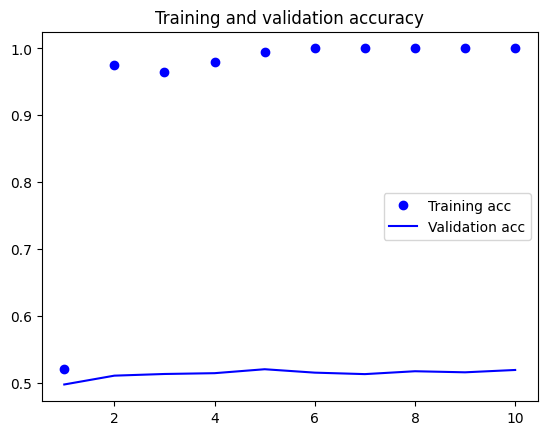

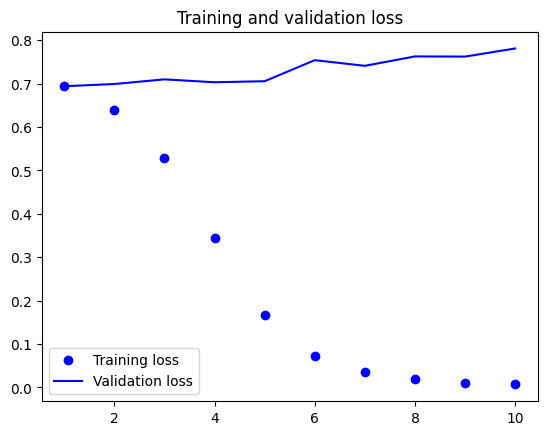

In [67]:
import matplotlib.pyplot as plt

acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

Level 2 Regularization Model - Accuracy: 0.5047793984413147

In [69]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense
from keras import regularizers

model = Sequential()
model.add(Embedding(max_words, embedding_dim, input_length=maxlen))
model.add(Flatten())
model.add(Dense(32, kernel_regularizer=regularizers.l2(0.001), activation='relu', input_shape=(10000,)))
model.add(Dense(32, kernel_regularizer=regularizers.l2(0.001), activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['acc'])
history = model.fit(x_train, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_data=(x_val, y_val))
model.save_weights('/content/sample_data/pre_trained_glove_model.weights.h5')
model.layers[0].set_weights([embedding_matrix])
model.layers[0].trainable = False
print("Expected embedding shape:", model.layers[0].get_weights()[0].shape)
print("Actual embedding matrix shape:", embedding_matrix.shape)

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 375ms/step - acc: 0.5359 - loss: 0.7861 - val_acc: 0.4944 - val_loss: 0.7825
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 233ms/step - acc: 0.9653 - loss: 0.7269 - val_acc: 0.5031 - val_loss: 0.7806
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 204ms/step - acc: 0.9950 - loss: 0.6271 - val_acc: 0.4964 - val_loss: 0.7944
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 231ms/step - acc: 0.9950 - loss: 0.4479 - val_acc: 0.5155 - val_loss: 0.8027
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 210ms/step - acc: 1.0000 - loss: 0.2732 - val_acc: 0.5193 - val_loss: 0.8097
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 231ms/step - acc: 1.0000 - loss: 0.1741 - val_acc: 0.5122 - val_loss: 0.8331
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 232ms/step - acc: 1.0000 - loss: 0.1330 - val_acc: 0.5161 - val_loss: 0.8424
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 458ms/step - acc: 1.0000 - loss: 0.1138 - val_acc: 0.5143 - val_loss: 0.8545
Epoch 9/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 233ms/step - acc: 1.0000 - loss: 0.1039 - va

In [70]:
results = model.evaluate(x_test, y_test)
results

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.5571 - loss: 1.7508


[2.01139235496521, 0.5047793984413147]

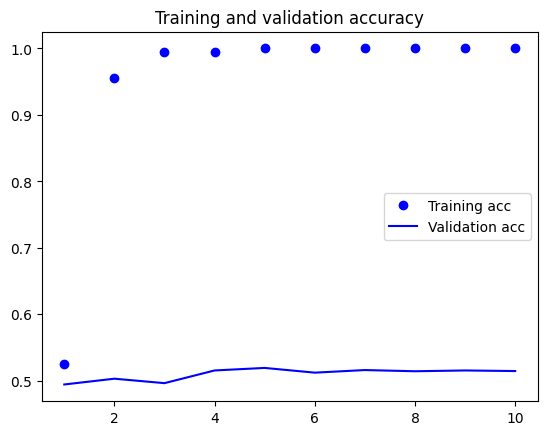

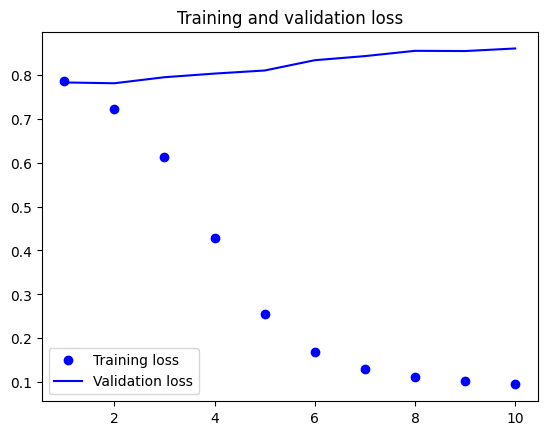

In [71]:
import matplotlib.pyplot as plt

acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

Dropout Model - Accuracy: 0.5033395886421204

In [75]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense
from keras import regularizers

array = []
model = Sequential()
model.add(Embedding(max_words, embedding_dim, input_length=maxlen))
model.add(Flatten())
model.add(Dense(32, activation='relu'))
model.add(layers.Dropout(0.8))
model.add(Dense(32, activation='relu'))
model.add(layers.Dropout(0.8))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['acc'])
history = model.fit(x_train, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_data=(x_val, y_val))
model.save_weights('/content/sample_data/pre_trained_glove_model.weights.h5')
model.layers[0].set_weights([embedding_matrix])
model.layers[0].trainable = False
print("Expected embedding shape:", model.layers[0].get_weights()[0].shape)
print("Actual embedding matrix shape:", embedding_matrix.shape)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 217ms/step - acc: 0.5343 - loss: 0.6948 - val_acc: 0.4932 - val_loss: 0.6935
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 454ms/step - acc: 0.4867 - loss: 0.7176 - val_acc: 0.4936 - val_loss: 0.6933
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 230ms/step - acc: 0.5730 - loss: 0.6836 - val_acc: 0.4970 - val_loss: 0.6933
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 229ms/step - acc: 0.4007 - loss: 0.7268 - val_acc: 0.5038 - val_loss: 0.6934
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 231ms/step - acc: 0.5424 - loss: 0.6868 - val_acc: 0.5018 - val_loss: 0.6935
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 194ms/step - acc: 0.4868 - loss: 0.7086 - val_acc: 0.4986 - val_loss: 0.6936
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 230ms/step - acc: 0.6077 - loss: 0.6785 - val_acc: 0.4997 - val_loss: 0.6935
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 452ms/step - acc: 0.5157 - loss: 0.7176 - val_acc: 0.5064 - val_loss: 0.6931
Epoch 9/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 230ms/step - acc: 0.4722 - loss: 

### Dropout Rate Test 1 [loss, accuracy]:

[[0.775414228439331, 0.5100588202476501], (0.1)

 [0.7938141226768494, 0.517457902431488], (0.2)

 [0.822445809841156, 0.5176178812980652], (0.3)

 [0.743547797203064, 0.5122185349464417], (0.4)

 [0.739944338798523, 0.509898841381073], (0.5)

 [0.7079647183418274, 0.5170179605484009], (0.6)

 [0.6938772797584534, 0.5061392784118652], (0.7)

 [0.6936200261116028, 0.5038595199584961]] (0.8)

### Dropout Rate Test 2 [loss, accuracy]:

[[0.8073393702507019, 0.514218270778656], (0.1)

 [0.783066987991333, 0.5181378126144409], (0.2)

 [0.7965855002403259, 0.5152581930160522], (0.3)

 [0.7536121606826782, 0.5107787251472473], (0.4)

 [0.7261520624160767, 0.5116186141967773], (0.5)

 [0.7170692682266235, 0.5068591833114624], (0.6)

 [0.6970271468162537, 0.510178804397583], (0.7)

 [0.6933171153068542, 0.5100188255310059]] (0.8)

 ### Dropout Rate Test 3 [loss, accuracy]:

 [[0.8258309960365295, 0.5064992308616638], (0.1)

 [0.8083478212356567, 0.5110986828804016], (0.2)

 [0.7672058343887329, 0.5134983658790588], (0.3)

 [0.8199278712272644, 0.5084189772605896], (0.4)

 [0.7206737399101257, 0.5117385983467102], (0.5)

 [0.7056694030761719, 0.5126184821128845], (0.6)

 [0.6935767531394958, 0.5068191885948181], (0.7)

 [0.6928470730781555, 0.5152581930160522]] (0.8)

 ### Optimal Dropout Rate (considering loss and accuracy): *0.8*


In [76]:
results = model.evaluate(x_test, y_test)
results

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.2565 - loss: 0.8951


[0.7370697259902954, 0.5033395886421204]

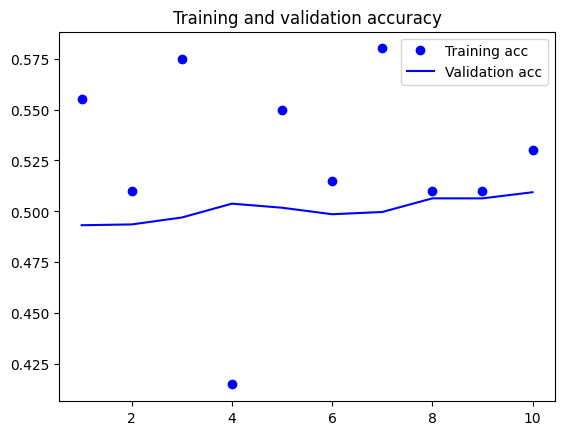

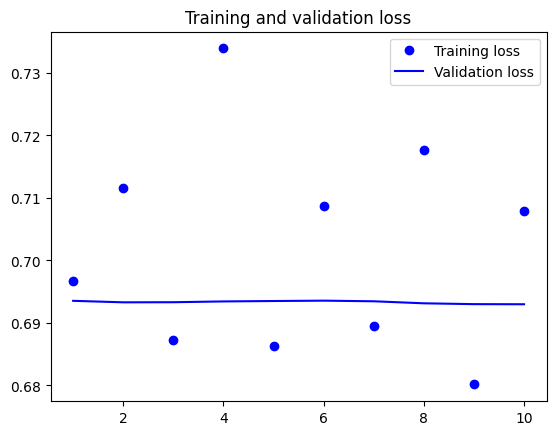

In [77]:
import matplotlib.pyplot as plt

acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

#TASK 2

Generate the confusion matrix

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
[[ 1833 10667]
 [ 1751 10752]]


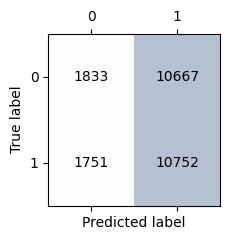

In [78]:
#Modified code from slides
from sklearn.metrics import confusion_matrix

y_pred_probs = model.predict(x_test)
y_pred = (y_pred_probs > 0.5).astype(int) # convert to binary 0 or 1
confmat = confusion_matrix(y_test, y_pred)
print(confmat)

fig, ax = plt.subplots(figsize=(2.5, 2.5))
ax.matshow(confmat, cmap=plt.cm.Blues, alpha=0.3)
for i in range(confmat.shape[0]):
    for j in range(confmat.shape[1]):
        ax.text(x=j, y=i, s=confmat[i, j], va='center', ha='center')

plt.xlabel('Predicted label')
plt.ylabel('True label')

plt.tight_layout()
plt.show()

## Matrices:
#### Original Model: [[6632 5868], [6558 5945]]
#### Regularization Model: [[7250 5250], [7132 5371]]
#### Dropout Model: [[ 1833 10667], [1751 10752]]

#TASK 3

Preparing the imdb data

In [ ]:
from tensorflow.keras import preprocessing
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence

# Number of words to consider as features
max_features = 10000
maxlen = 500
batch_size = 32

# Load the data as lists of integers.
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

# This turns our lists of integers
# into a 2D integer tensor of shape `(samples, maxlen)`
x_train = preprocessing.sequence.pad_sequences(x_train, maxlen=maxlen)
x_test = preprocessing.sequence.pad_sequences(x_test, maxlen=maxlen)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Testing original model

In [ ]:
from tensorflow.keras.layers import Flatten, Dense

model = Sequential()
# We specify the maximum input length to our Embedding layer
# so we can later flatten the embedded inputs
model.add(Embedding(max_features, 32))
# After the Embedding layer,
# our activations have shape `(samples, maxlen, 8)`.

# We flatten the 3D tensor of embeddings
# into a 2D tensor of shape `(samples, maxlen * 8)`
model.add(Flatten())

# We add the classifier on top
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])

history = model.fit(x_train, y_train, epochs=10, batch_size=128, validation_split=0.2)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - acc: 0.5661 - loss: 0.6798 - val_acc: 0.7776 - val_loss: 0.5153
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - acc: 0.8172 - loss: 0.4468 - val_acc: 0.8394 - val_loss: 0.3687
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - acc: 0.8733 - loss: 0.3136 - val_acc: 0.8552 - val_loss: 0.3336
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - acc: 0.9049 - loss: 0.2538 - val_acc: 0.8434 - val_loss: 0.3530
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - acc: 0.9239 - loss: 0.2066 - val_acc: 0.8614 - val_loss: 0.3281
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - acc: 0.9473 - loss: 0.1670 - val_acc: 0.8666 - val_loss: 0.3184
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - acc: 0.9568 - loss: 0.1371 - val_acc: 0.8646 - val_loss: 0.3226
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - acc: 0.9697 - loss: 0.1141 - val_acc: 0.8416 - val_loss: 0.3966
Epoch 9/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/

In [ ]:
results = model.evaluate(x_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.8612 - loss: 0.3440


In [ ]:
results

[0.3485335409641266, 0.8611999750137329]

Test Accuracy: 0.8611999750137329

Testing SimpleRNN model

In [ ]:
from keras.layers import Dense
model = Sequential()
model.add(Embedding(max_features, 32))
model.add(SimpleRNN(32))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
history = model.fit(x_train, y_train, epochs=10, batch_size=128, validation_split=0.2)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 31s 181ms/step - acc: 0.5446 - loss: 0.6806 - val_acc: 0.7480 - val_loss: 0.5257
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 27s 170ms/step - acc: 0.7937 - loss: 0.4602 - val_acc: 0.8462 - val_loss: 0.3822
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 44s 189ms/step - acc: 0.8560 - loss: 0.3527 - val_acc: 0.8008 - val_loss: 0.4372
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 38s 170ms/step - acc: 0.8884 - loss: 0.2854 - val_acc: 0.8542 - val_loss: 0.3942
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 43s 180ms/step - acc: 0.9166 - loss: 0.2172 - val_acc: 0.8136 - val_loss: 0.4573
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 40s 172ms/step - acc: 0.9403 - loss: 0.1631 - val_acc: 0.8446 - val_loss: 0.3945
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 27s 172ms/step - acc: 0.9632 - loss: 0.1100 - val_acc: 0.8314 - val_loss: 0.6275
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 27s 170ms/step - acc: 0.9646 - loss: 0.1030 - val_acc: 0.8436 - val_loss: 0.4604
Epoch 9/10
157/157 ━━━━━━━━━━━━━

In [ ]:
results = model.evaluate(x_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - acc: 0.8046 - loss: 0.6333


In [ ]:
results

[0.6207876205444336, 0.8082399964332581]

Test Accuracy: 0.8082399964332581